# Improved Textbook Q&A Extraction Pipeline (Parallel Processing)

This notebook implements a 3-step process with parallel processing:
1. **Question/Answer Extraction** - Extract full problem content using regex
2. **Quality Validation** - Filter out references to figures/tables (PARALLEL)
3. **Reformatting** - Separate into Question, Reasoning, and Answer (PARALLEL)

**Performance:** Uses Claude Haiku with 10 concurrent requests for ~20-30x speedup

## Setup and Imports

In [ ]:
import re
import json
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass, field
from openai import OpenAI
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

# Initialize OpenRouter client
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key='' #add api key here
)

# Global token counter with thread safety
total_tokens = 0
token_lock = threading.Lock()

## Configuration

In [2]:
@dataclass
class Config:
    """Configuration for extraction pipeline"""
    # File paths
    textbooks_dir: str = "../mistral ocr"
    output_dir: str = "../content"
    
    # Extraction parameters
    keywords: List[str] = field(default_factory=lambda: ['example', 'problem', 'exercise', 'homework'])
    min_content_length: int = 1000
    max_content_length: int = 12500
    
    # LLM parameters - HAIKU for speed
    model: str = "anthropic/claude-3-haiku"
    temperature: float = 0.1
    max_tokens: int = 4000
    
    # Parallel processing
    max_workers: int = 10  # Number of concurrent API requests

config = Config()
Path(config.output_dir).mkdir(exist_ok=True)

print(f"✓ Configuration:")
print(f"  Model: {config.model}")
print(f"  Max workers: {config.max_workers}")
print(f"  Textbooks: {Path(config.textbooks_dir).absolute()}")
print(f"  Output: {Path(config.output_dir).absolute()}")

✓ Configuration:
  Model: anthropic/claude-3-haiku
  Max workers: 10
  Textbooks: c:\Users\alexa\OneDrive\Documents\CentraleSupelec\Reaserch Project\Reliability-Domain-Specific-LLM\extractors\..\mistral ocr
  Output: c:\Users\alexa\OneDrive\Documents\CentraleSupelec\Reaserch Project\Reliability-Domain-Specific-LLM\extractors\..\content


## Step 1: Raw Content Extraction

Extract questions and their complete solution content using regex.

In [3]:
def clean_text(text: str) -> str:
    """Clean and normalize text"""
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)
    # Remove page numbers and common artifacts
    text = re.sub(r'\bpage\s+\d+\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\d+\s+chapter\s+\d+', '', text, flags=re.IGNORECASE)
    return text.strip()


def extract_raw_content(text: str, filename: str, config: Config) -> List[Dict]:
    """
    Extract raw question+solution content blocks.
    
    Returns list of dicts with:
    - source: identifier (e.g., "[file_1] Example 2.5")
    - raw_content: full text including question and solution
    """
    results = []
    
    # Build regex pattern for all keywords
    keywords_pattern = '|'.join(config.keywords)
    pattern = rf'\b({keywords_pattern})\s+([\d.]+)'
    
    # Find all matches
    matches = list(re.finditer(pattern, text, re.IGNORECASE))
    
    for i, match in enumerate(matches):
        keyword = match.group(1)
        number = match.group(2)
        source = f"[{filename}] {keyword.title()} {number}"
        
        # Extract content from this match to the next one (or end)
        start_pos = match.start()
        if i < len(matches) - 1:
            end_pos = matches[i + 1].start()
        else:
            end_pos = min(start_pos + config.max_content_length, len(text))
        
        raw_content = text[start_pos:end_pos]
        raw_content = clean_text(raw_content)
        
        # Only keep if meets length requirements
        if config.min_content_length <= len(raw_content) <= config.max_content_length:
            results.append({
                'source': source,
                'raw_content': raw_content
            })
    
    return results


def extract_from_all_files(config: Config) -> List[Dict]:
    """Extract raw content from all markdown files"""
    textbooks_path = Path(config.textbooks_dir)
    all_raw = []
    
    md_files = list(textbooks_path.glob("*.md"))
    print(f"Found {len(md_files)} markdown files\n")
    
    for md_file in tqdm(md_files, desc="Extracting raw content"):
        try:
            with open(md_file, 'r', encoding='utf-8') as f:
                text = f.read()
            
            filename = md_file.stem
            extracted = extract_raw_content(text, filename, config)
            all_raw.extend(extracted)
            
        except Exception as e:
            print(f"Error processing {md_file.name}: {e}")
    
    print(f"\nExtracted {len(all_raw)} raw question blocks")
    return all_raw

## Step 2: Quality Validation (PARALLEL)

Use LLM to validate that questions are self-contained and don't reference external figures/tables.

In [4]:
VALIDATION_PROMPT = """You are validating textbook questions for a reliability engineering Q&A dataset.

A question is VALID if ALL of the following are true:
1. It is self-contained - all necessary information is provided in the text
2. It does NOT reference figures, tables, diagrams, or charts that are not included but are relevant to the question
3. It does NOT say "use the above", "from the previous", "as shown", etc. referring to external content not in the provided text
4. It has a clear, definite answer (could be numerical, analytical, or conceptual)
5. The text is complete and not cut off
6. It requires meaningful reasoning (not just a definition lookup)

A question is NOT VALID if ANY of the following are true:
- References "Figure X", "Table Y", "the above diagram", etc. that aren't in the text but are necessary to answer the question
- Says "use data from Table 3.2" when the table isn't provided
- Is incomplete or cut off mid-sentence
- Is too vague or open-ended without clear criteria
- Is a meta-question about the textbook itself

IMPORTANT: Even if a table/figure is mentioned but the data IS provided in the text, it's VALID.

Content to validate:
{content}

Respond with ONLY one word: "VALID" or "INVALID"""


def validate_single_item(item: Dict, config: Config) -> Tuple[Dict, bool, str]:
    """
    Validate a single content block (thread-safe).
    Returns: (item, is_valid, reason)
    """
    prompt = VALIDATION_PROMPT.format(content=item['raw_content'])
    
    try:
        response = client.chat.completions.create(
            model=config.model,
            max_tokens=100,  # Validation only needs short response
            temperature=config.temperature,
            messages=[{"role": "user", "content": prompt}]
        )
        
        # Thread-safe token counting
        global total_tokens
        with token_lock:
            total_tokens += response.usage.prompt_tokens + response.usage.completion_tokens
        
        # Parse response
        text = response.choices[0].message.content
        lines = text.strip().split('\n')
        decision = lines[0].strip().upper()
        reason = lines[1].strip() if len(lines) > 1 else ""
        
        is_valid = "VALID" in decision and "INVALID" not in decision
        return item, is_valid, reason
        
    except Exception as e:
        return item, False, str(e)


def validate_all_parallel(raw_items: List[Dict], config: Config) -> List[Dict]:
    """Validate all raw content blocks in parallel"""
    validated = []
    errors = []
    
    print(f"Starting parallel validation with {config.max_workers} workers...")
    
    with ThreadPoolExecutor(max_workers=config.max_workers) as executor:
        # Submit all tasks
        future_to_item = {
            executor.submit(validate_single_item, item, config): item 
            for item in raw_items
        }
        
        # Collect results with progress bar
        for future in tqdm(as_completed(future_to_item), total=len(raw_items), desc="Validating"):
            try:
                item, is_valid, reason = future.result()
                
                if is_valid:
                    item['validation_reason'] = reason
                    validated.append(item)
                    
            except Exception as e:
                item = future_to_item[future]
                errors.append(f"{item['source']}: {e}")
    
    print(f"\nValidation complete:")
    print(f"  Valid: {len(validated)} / {len(raw_items)} ({len(validated)/len(raw_items)*100:.1f}%)")
    print(f"  Errors: {len(errors)}")
    print(f"  Tokens used: {total_tokens:,}")
    
    if errors and len(errors) <= 10:
        print(f"\n  Error samples:")
        for err in errors[:5]:
            print(f"    - {err}")
    
    return validated

## Step 3: Reformatting into Q/R/A (PARALLEL)

Separate validated content into Question, Reasoning, and Answer components.

In [5]:
REFORMATTING_PROMPT = """You are reformatting textbook problems into structured Question-Reasoning-Answer format.

Given the following textbook content, extract and separate it into THREE components:

1. QUESTION: The problem statement only. Include:
   - The problem description
   - All given data and parameters
   - What is being asked
   - For multi-part questions, include ALL parts (a, b, c, etc.)

2. REASONING: The solution methodology and working. Include:
   - Step-by-step solution process
   - Formulas and equations used
   - Intermediate calculations
   - Logical reasoning and explanations
   - For multi-part questions, include reasoning for ALL parts

3. ANSWER: Only the final answer(s). Format:
   - For single answer: just the value (e.g., "0.95" or "1500 hours")
   - For multi-part: comma-separated (e.g., "0.85, 1200, True")
   - For multiple values: comma-separated (e.g., "0.3, 0.4, 0.5")
   - No units unless critical for understanding
   - No explanatory text, just the answer(s)

Content to reformat:
{content}

Respond in this exact format:
QUESTION:
[question text]

REASONING:
[reasoning text]

ANSWER:
[answer only]

IMPORTANT:
- If this is a multi-part question (a, b, c, etc.), include ALL parts in question and provide ALL answers
- Keep mathematical notation (LaTeX) intact
- Be complete but concise
- The answer should be extractable as a simple value or comma-separated values"""


def parse_qra_response(response: str) -> Optional[Dict[str, str]]:
    """Parse LLM response into Q/R/A components"""
    try:
        # Extract sections using regex
        question_match = re.search(r'QUESTION:\s*\n(.+?)(?=\n\s*REASONING:)', response, re.DOTALL)
        reasoning_match = re.search(r'REASONING:\s*\n(.+?)(?=\n\s*ANSWER:)', response, re.DOTALL)
        answer_match = re.search(r'ANSWER:\s*\n(.+?)$', response, re.DOTALL)
        
        if not (question_match and reasoning_match and answer_match):
            return None
        
        return {
            'question': question_match.group(1).strip(),
            'reasoning': reasoning_match.group(1).strip(),
            'answer': answer_match.group(1).strip()
        }
    except Exception:
        return None


def reformat_single_item(item: Dict, config: Config) -> Tuple[Dict, Optional[Dict]]:
    """
    Reformat a single validated content block into Q/R/A (thread-safe).
    Returns: (original_item, result_dict or None)
    """
    prompt = REFORMATTING_PROMPT.format(content=item['raw_content'])
    
    try:
        response = client.chat.completions.create(
            model=config.model,
            max_tokens=config.max_tokens,
            temperature=config.temperature,
            messages=[{"role": "user", "content": prompt}]
        )
        
        # Thread-safe token counting
        global total_tokens
        with token_lock:
            total_tokens += response.usage.prompt_tokens + response.usage.completion_tokens
        
        text = response.choices[0].message.content
        qra = parse_qra_response(text)
        
        if qra:
            return item, {
                'source': item['source'],
                'question': qra['question'],
                'reasoning': qra['reasoning'],
                'answer': qra['answer']
            }
        else:
            return item, None
            
    except Exception as e:
        return item, None


def reformat_all_parallel(validated_items: List[Dict], config: Config) -> List[Dict]:
    """Reformat all validated items into Q/R/A format in parallel"""
    reformatted = []
    errors = []
    
    print(f"Starting parallel reformatting with {config.max_workers} workers...")
    
    with ThreadPoolExecutor(max_workers=config.max_workers) as executor:
        # Submit all tasks
        future_to_item = {
            executor.submit(reformat_single_item, item, config): item 
            for item in validated_items
        }
        
        # Collect results with progress bar
        for future in tqdm(as_completed(future_to_item), total=len(validated_items), desc="Reformatting"):
            try:
                item, result = future.result()
                
                if result:
                    reformatted.append(result)
                else:
                    errors.append(item['source'])
                    
            except Exception as e:
                item = future_to_item[future]
                errors.append(f"{item['source']}: {e}")
    
    print(f"\nReformatting complete:")
    print(f"  Successful: {len(reformatted)} / {len(validated_items)} ({len(reformatted)/len(validated_items)*100:.1f}%)")
    print(f"  Failed to parse: {len(errors)}")
    print(f"  Total tokens used: {total_tokens:,}")
    
    if errors and len(errors) <= 10:
        print(f"\n  Failed items:")
        for err in errors[:5]:
            print(f"    - {err}")
    
    return reformatted

## Pipeline Execution

In [6]:
def save_jsonl(data: List[Dict], filename: str):
    """Save data to JSONL file"""
    filepath = Path(config.output_dir) / filename
    with open(filepath, 'w', encoding='utf-8') as f:
        for item in data:
            f.write(json.dumps(item, ensure_ascii=False) + '\n')
    print(f"Saved to: {filepath}")


def run_pipeline(config: Config, save_intermediate: bool = True):
    """
    Run the complete extraction pipeline with parallel processing.
    
    Args:
        config: Configuration object
        save_intermediate: Whether to save intermediate results
    
    Returns:
        final_dataset: List of Q/R/A dictionaries
    """
    print("="*80)
    print("TEXTBOOK Q&A EXTRACTION PIPELINE (PARALLEL)")
    print("="*80)
    print(f"Model: {config.model}")
    print(f"Workers: {config.max_workers}")
    print("="*80)
    
    # Step 1: Extract raw content
    print("\n[STEP 1] Extracting raw question+solution blocks...")
    raw_items = extract_from_all_files(config)
    if save_intermediate:
        save_jsonl(raw_items, "step1_raw_content.jsonl")
    
    if not raw_items:
        print("No content extracted. Check your textbooks directory.")
        return None
    
    # Step 2: Validate content (PARALLEL)
    print("\n[STEP 2] Validating content quality (PARALLEL)...")
    validated_items = validate_all_parallel(raw_items, config)
    if save_intermediate:
        save_jsonl(validated_items, "step2_validated_content.jsonl")
    
    if not validated_items:
        print("No valid content after validation.")
        return None
    
    # Step 3: Reformat into Q/R/A (PARALLEL)
    print("\n[STEP 3] Reformatting into Question/Reasoning/Answer (PARALLEL)...")
    final_dataset = reformat_all_parallel(validated_items, config)
    
    if final_dataset:
        save_jsonl(final_dataset, "final_qra_dataset.jsonl")
    
    # Summary
    print("\n" + "="*80)
    print("PIPELINE COMPLETE")
    print("="*80)
    print(f"Raw extracted:     {len(raw_items)}")
    print(f"Validated:         {len(validated_items)} ({len(validated_items)/len(raw_items)*100:.1f}%)")
    print(f"Final dataset:     {len(final_dataset)} ({len(final_dataset)/len(raw_items)*100:.1f}%)")
    print(f"Total tokens used: {total_tokens:,}")
    print(f"Est. cost (Haiku): ${total_tokens * 0.00000025:.2f}")
    print("="*80)
    
    return final_dataset

## Run the Pipeline

In [7]:
# Run the complete pipeline with parallel processing
final_dataset = run_pipeline(config, save_intermediate=True)

TEXTBOOK Q&A EXTRACTION PIPELINE (PARALLEL)
Model: anthropic/claude-3-haiku
Workers: 10

[STEP 1] Extracting raw question+solution blocks...
Found 32 markdown files



Extracting raw content:   0%|          | 0/32 [00:00<?, ?it/s]


Extracted 1789 raw question blocks
Saved to: ..\content\step1_raw_content.jsonl

[STEP 2] Validating content quality (PARALLEL)...
Starting parallel validation with 10 workers...


Validating:   0%|          | 0/1789 [00:00<?, ?it/s]


Validation complete:
  Valid: 1395 / 1789 (78.0%)
  Errors: 0
  Tokens used: 2,522,831
Saved to: ..\content\step2_validated_content.jsonl

[STEP 3] Reformatting into Question/Reasoning/Answer (PARALLEL)...
Starting parallel reformatting with 10 workers...


Reformatting:   0%|          | 0/1395 [00:00<?, ?it/s]


Reformatting complete:
  Successful: 508 / 1395 (36.4%)
  Failed to parse: 887
  Total tokens used: 3,675,061
Saved to: ..\content\final_qra_dataset.jsonl

PIPELINE COMPLETE
Raw extracted:     1789
Validated:         1395 (78.0%)
Final dataset:     508 (28.4%)
Total tokens used: 3,675,061
Est. cost (Haiku): $0.92


## Inspect Results

In [8]:
# Show sample results
if final_dataset:
    print("\n" + "="*80)
    print("SAMPLE RESULTS")
    print("="*80)
    
    for i, item in enumerate(final_dataset[:3]):
        print(f"\n[{i+1}] {item['source']}")
        print("\nQUESTION:")
        print(item['question'][:300] + "..." if len(item['question']) > 300 else item['question'])
        print("\nREASONING:")
        print(item['reasoning'][:300] + "..." if len(item['reasoning']) > 300 else item['reasoning'])
        print("\nANSWER:")
        print(item['answer'])
        print("\n" + "-"*80)


SAMPLE RESULTS

[1] [file_1] Example 13.1

QUESTION:
The problem describes a set of fatigue $S-N$ data of welded exhaust components made of a steel, with tests conducted by controlling the applied load and only two load levels tested with six data points at each load level. The data show a wide scatter band due to factors such as material inhomogeneit...

REASONING:
1. The horizontal offsets method and the vertical offset method are used to fit the fatigue $S-N$ data.
2. The horizontal offsets method provides a reasonable fit curve, while the vertical offset method provides a poor fit to the set of data.
3. The results of the horizontal offset method are very d...

ANSWER:
0.3, 0.4, 0.5

--------------------------------------------------------------------------------

[2] [file_1] Example 7.2

QUESTION:
Suppose there is one spare unit available for replacement, the operating unit is replaced preventively with the spare one at time $T(0<T \leq \infty)$, and the spare unit should operat

## Analysis and Statistics


DATASET STATISTICS
Total Q&A pairs: 508
Multi-part questions: 315 (62.0%)

Length Statistics:
       question_length  reasoning_length  answer_length
count       508.000000        508.000000     508.000000
mean        426.846457        738.848425     475.474409
std         308.755573        375.836192    1688.691788
min          34.000000        102.000000       1.000000
25%         240.000000        478.000000       7.000000
50%         352.000000        673.000000      16.000000
75%         526.250000        931.000000      72.250000
max        3261.000000       3792.000000   11288.000000


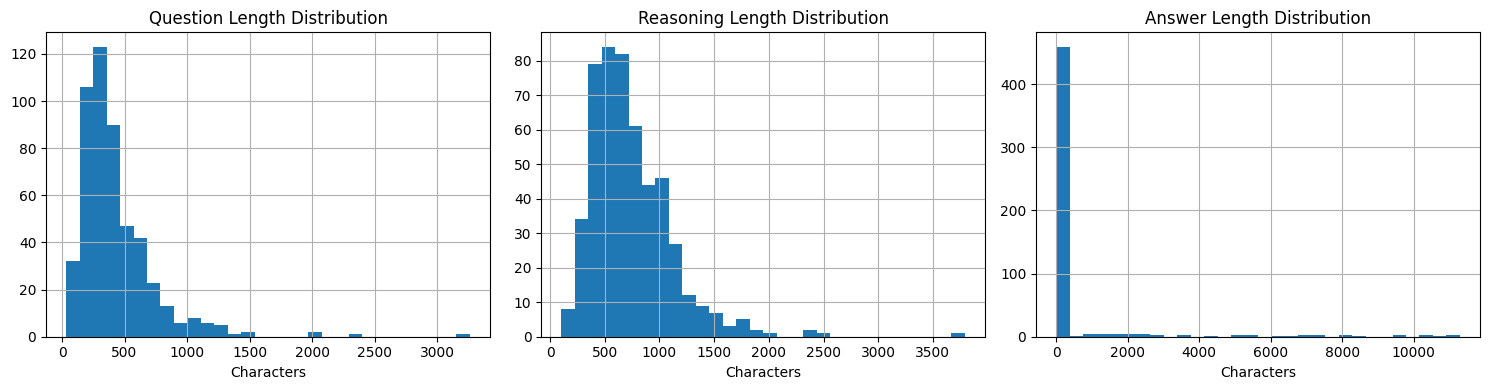

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

if final_dataset:
    # Create dataframe for analysis
    df = pd.DataFrame(final_dataset)
    
    # Length statistics
    df['question_length'] = df['question'].str.len()
    df['reasoning_length'] = df['reasoning'].str.len()
    df['answer_length'] = df['answer'].str.len()
    
    # Multi-part detection (check for commas in answers)
    df['is_multipart'] = df['answer'].str.contains(',')
    
    print("\nDATASET STATISTICS")
    print("="*80)
    print(f"Total Q&A pairs: {len(df)}")
    print(f"Multi-part questions: {df['is_multipart'].sum()} ({df['is_multipart'].sum()/len(df)*100:.1f}%)")
    print("\nLength Statistics:")
    print(df[['question_length', 'reasoning_length', 'answer_length']].describe())
    
    # Plot distributions
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    df['question_length'].hist(bins=30, ax=axes[0])
    axes[0].set_title('Question Length Distribution')
    axes[0].set_xlabel('Characters')
    
    df['reasoning_length'].hist(bins=30, ax=axes[1])
    axes[1].set_title('Reasoning Length Distribution')
    axes[1].set_xlabel('Characters')
    
    df['answer_length'].hist(bins=30, ax=axes[2])
    axes[2].set_title('Answer Length Distribution')
    axes[2].set_xlabel('Characters')
    
    plt.tight_layout()
    plt.show()

## Export to Different Formats

In [10]:
if final_dataset:
    # Export as CSV
    df.to_csv(Path(config.output_dir) / "final_dataset.csv", index=False)
    print("✓ Exported to CSV")
    
    # Export as standard JSON
    with open(Path(config.output_dir) / "final_dataset.json", 'w', encoding='utf-8') as f:
        json.dump(final_dataset, f, indent=2, ensure_ascii=False)
    print("✓ Exported to JSON")
    
    # Export for fine-tuning (Q+R -> A format)
    finetuning_data = []
    for item in final_dataset:
        finetuning_data.append({
            "messages": [
                {
                    "role": "user",
                    "content": f"Question: {item['question']}\n\nProvide a detailed solution with reasoning."
                },
                {
                    "role": "assistant",
                    "content": f"Reasoning:\n{item['reasoning']}\n\nAnswer: {item['answer']}"
                }
            ]
        })
    
    with open(Path(config.output_dir) / "finetuning_format.jsonl", 'w', encoding='utf-8') as f:
        for item in finetuning_data:
            f.write(json.dumps(item, ensure_ascii=False) + '\n')
    print("✓ Exported fine-tuning format")
    
    print(f"\nAll files saved to: {Path(config.output_dir).absolute()}")

✓ Exported to CSV
✓ Exported to JSON
✓ Exported fine-tuning format

All files saved to: c:\Users\alexa\OneDrive\Documents\CentraleSupelec\Reaserch Project\Reliability-Domain-Specific-LLM\extractors\..\content
